In [1]:
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [2]:
plt.rcParams['figure.max_open_warning'] = 0

plt.rcParams['text.usetex']        = True
    
# plt.rcParams['mathtext.fontset']  = 'stix'
# plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

In [3]:
import sxs
import numpy as np
df = sxs.load("dataframe", tag="v3.0.0")
chi_eff = [0.9794, 0.9695, 0.9496, 0.8997,0.8498, 0.7999, 0.6000, 0.43655,0.2000, 0, -0.2000, -0.43756, -0.5999, -0.7998, -0.8996, -0.9495]
df = df.undeprecated[df.undeprecated["object_types"] == "BHBH"]
mask = np.isclose(df.reference_chi_eff.values[:, None], chi_eff, atol=1e-3).any(axis=1) 
mask &= np.isclose(df.reference_mass_ratio.values[:, None], 1, atol=1e-6).any(axis=1)
sxs_ids = df[mask].index
chis = df[mask].reference_chi_eff
q = df[mask].reference_mass_ratio

In [4]:
df = pd.read_csv('../../data/SXS_Parameters.csv')
mask = df['catalog'] == 'SXS'
#https://arxiv.org/pdf/2001.09082
#Follows q=m1/m2>=1
# mass_ratio = m2/m1 <= 1
q = 1/df.loc[mask, 'q'].values
sxs_ids = df.loc[mask, 'ID'].astype(int).values
sxs_ids = [str(i).zfill(4) for i in sxs_ids]
chi1 = df.loc[mask, 'chi1z'].values
chi2 = df.loc[mask, 'chi2z'].values
a_0 = (q*chi1 + chi2)/(q+1)
a_12 = (q*chi1 - chi2)/(q+1)
X_12 = (q-1)/(q+1)
S_hats = a_0 + X_12*a_12

In [5]:
c3A, c3p, c4p = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
c3A_err, c3p_err, c4p_err = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
full_data, S_hat, ids = [], [], []
for i, sxs_id in enumerate(sxs_ids):
    try:
        data = np.loadtxt(f'../../output/nc_qc_fits/qc_fits_sxs_equal-mass/SXS_{sxs_id}/Algorithm/posterior.dat')[:,[1,2,3]]
        c3A[i], c3p[i], c4p[i] = np.median(data, axis=0)
        c3A_err[i], c3p_err[i], c4p_err[i] = np.std(data, axis=0)
        full_data.append(data)
        S_hat.append(S_hats[i])
        ids.append(sxs_id)
    except:
        continue
c3A, c3p, c4p = c3A[c3A!=0], c3p[c3p!=0], c4p[c4p!=0]
c3A_err, c3p_err, c4p_err = c3A_err[c3A_err!=0], c3p_err[c3p_err!=0], c4p_err[c4p_err!=0]
S_hat = np.array(S_hat)

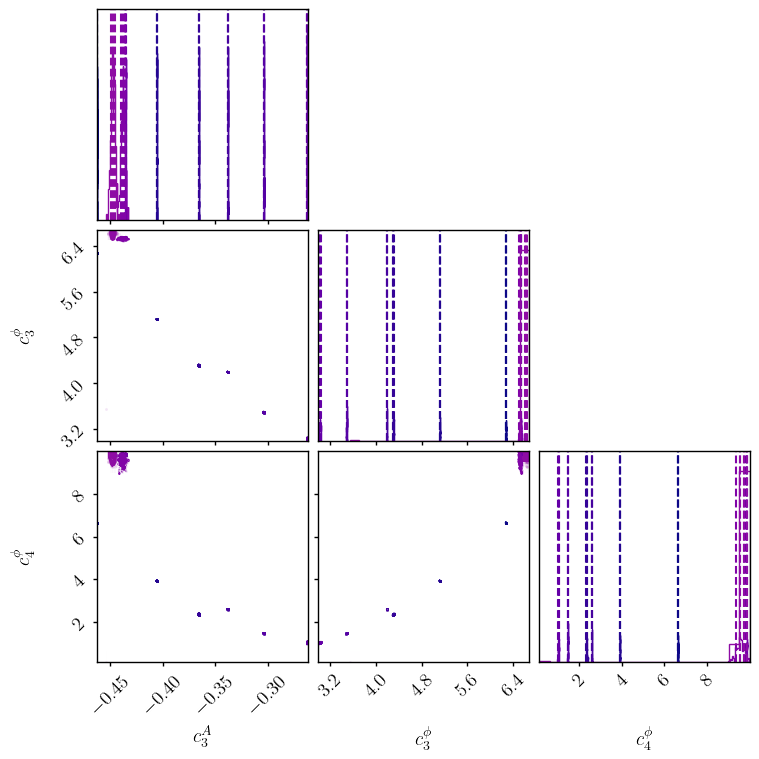

In [6]:
colors = [matplotlib.colormaps.get_cmap('plasma')(i) for i in np.linspace(0, 1, len(sxs_ids))]
ylabels = ['$c_3^A$', '$c_3^{\\phi}$', '$c_4^{\\phi}$']
fig = corner.corner(full_data[0],
                    labels=ylabels,
                    color=colors[0],
                    quantiles=(0.16, 0.5, 0.84))
for i, data in enumerate(full_data):
    if i == 0:
        continue
    fig = corner.corner(data,
                        labels=ylabels,
                        color=colors[i],
                        quantiles=(0.16, 0.5, 0.84),
                        fig=fig)
fig.set_size_inches(8, 8)
plt.show()

In [7]:
p3Achi, cov_p3A = np.polyfit(S_hat, c3A, 3, w=1/c3A_err, cov=True)
p3pchi, cov_p3p = np.polyfit(S_hat, c3p, 4, w=1/c3p_err, cov=True)
p4pchi, cov_p4p = np.polyfit(S_hat, c4p, 3, w=1/c4p_err, cov=True)
print('p3A:', p3Achi)
print('p3p:', p3pchi)
print('p4p:', p4pchi)

p3A: [ 0.09998554  0.00265376 -0.18285895 -0.37378546]
p3p: [-1.95822603  0.21659136  1.26218721  2.39128787  4.5902631 ]
p4p: [0.49737919 2.31050818 4.19508404 3.14891067]


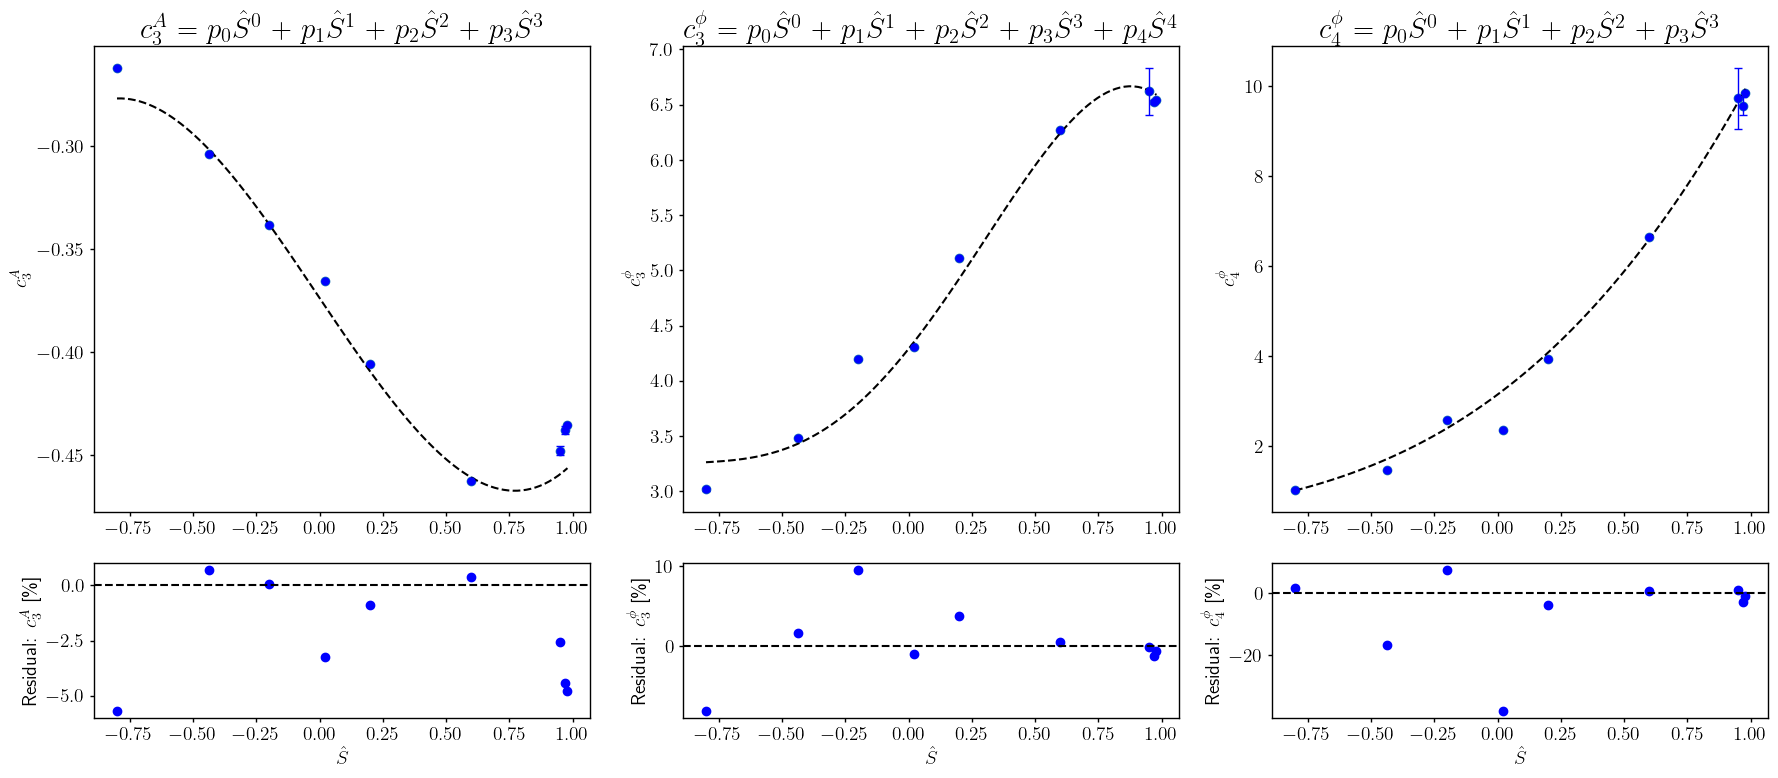

In [9]:
fig, ax = plt.subplots(2, 3, figsize=(18, 8), gridspec_kw={'height_ratios': [3, 1]})
plots, fits, errors = [c3A, c3p, c4p], [p3Achi, p3pchi, p4pchi], [c3A_err, c3p_err, c4p_err]
ylabels = ['$c_3^A$', '$c_3^{\\phi}$', '$c_4^{\\phi}$']
chispace = np.linspace(np.min(S_hat), np.max(S_hat), 100)
for i, (a_0, a_1, y, e, f, ylabel) in enumerate(zip(ax[0, :], ax[1, :],plots, errors, fits, ylabels)):    
    a_0.plot(chispace, np.polyval(f, chispace), label='Fit', color='k', linestyle='--')
    a_0.errorbar(S_hat, y, yerr=e, fmt='o', color='b', markersize=5, elinewidth=1, capsize=3)
    a_0.scatter(S_hat, y)
    a_0.set_ylabel(ylabel)
    poly_terms = []
    for j in range(len(f)):
        term = "$p_{{{}}} \\hat{{S}}^{{{}}}$".format(j, j)
        poly_terms.append(term)
    poly_string = " $+$ ".join(poly_terms)
    a_0.set_title("{} = {}".format(ylabel, poly_string))
    residual = 100*(y - np.polyval(f, S_hat))/y
    a_1.axhline(0, color='k', linestyle='--')
    a_1.scatter(S_hat, residual, color='b', marker='o')
    a_1.set_xlabel('$\\hat{{S}}$')
    a_1.set_ylabel('Residual: {ylabel} [\\%]'.format(ylabel=ylabel))
plt.tight_layout()
plt.show()

In [10]:
def get_mismatches(filename):
    mismatch = np.zeros(len(sxs_ids))
    for i, sxs_id in enumerate(sxs_ids):
        try:
            mismatch_row = np.genfromtxt(f'../../output/nc_qc_fits/{filename}/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                        dtype=None, names=True, encoding='utf-8', comments='#')
            mismatch_real = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0]
            mismatch_imag = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'imag']['Mismatch'][0]
            mismatch[i] = np.sqrt(mismatch_real**2 + mismatch_imag**2)
        except:
            continue
    mismatch = mismatch[mismatch!=0]
    return mismatch
mismatch = get_mismatches('qc_fits_sxs_equal-mass')

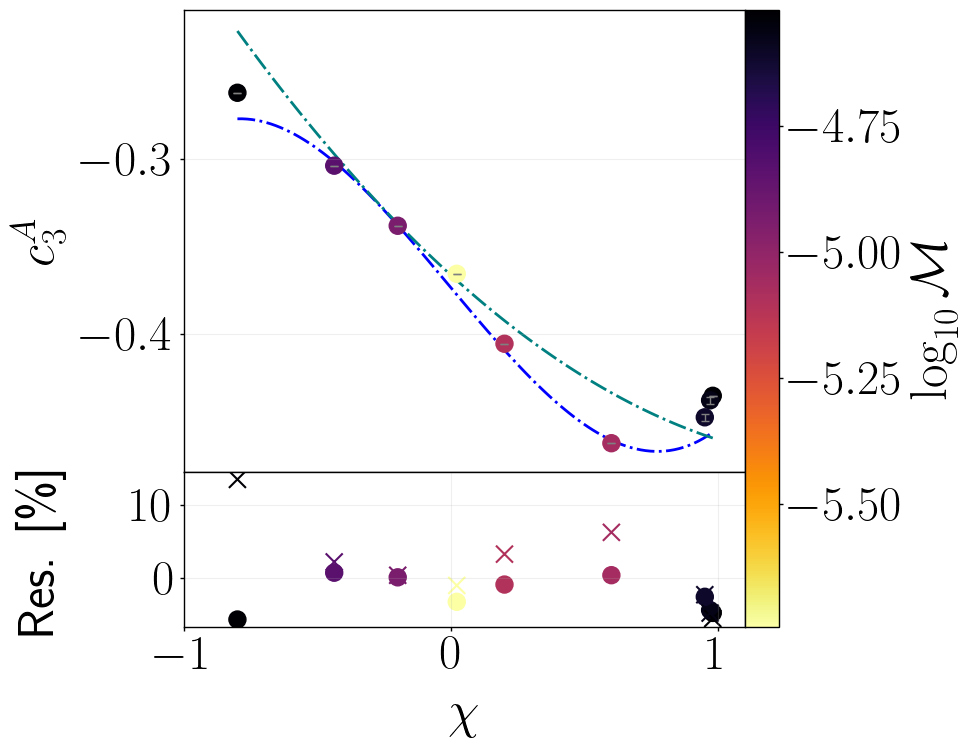

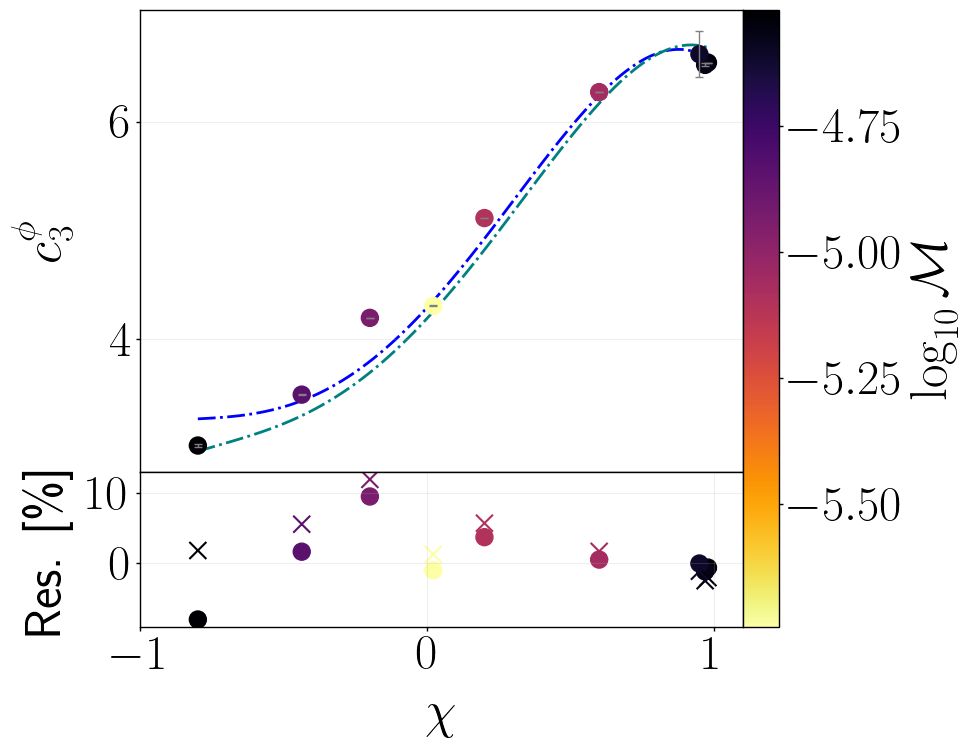

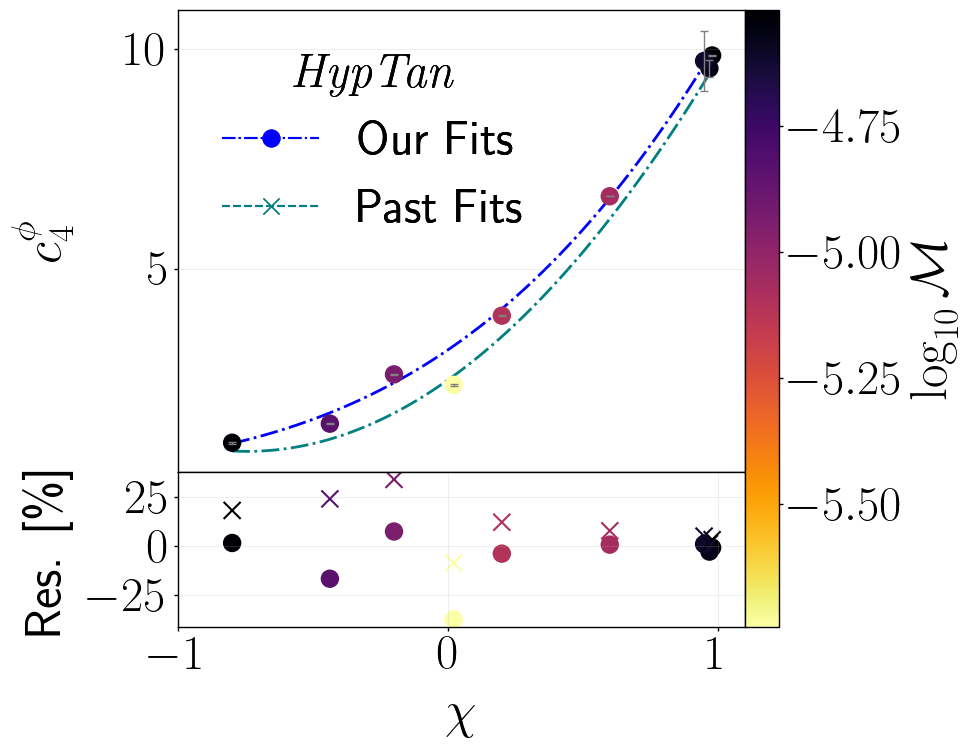

In [11]:
lw_fit      = 2
size_labels = 37
marker_size  = 150
ticklabelsize = 35
legendlabelsize = 35
ls_fit      = '-.'
color_fit   = 'blue'
palette_fig = 'inferno_r'

for i, (coeff, err, label, coeff_fit, lab) in enumerate(zip([c3A, c3p, c4p],
                                                             [c3A_err, c3p_err, c4p_err],
                                                             ylabels, fits, ['c3A', 'c3p', 'c4p'])):

    fig = plt.figure(figsize=(9*1.1,7*1.1))
    gs = fig.add_gridspec(nrows=4, ncols=2, width_ratios=[1, 0.06], hspace=0., wspace=0.)
    ax1 = fig.add_subplot(gs[:3, 0])
    ax2 = fig.add_subplot(gs[3, 0])
    cax = fig.add_subplot(gs[:, 1])
    ax1.errorbar(S_hat, coeff, yerr=err, markersize=5, linewidth=1, capsize=3, fmt='None', color='gray')
    sc = ax1.scatter(x=S_hat, y=coeff, c=np.log10(mismatch), cmap=palette_fig, s=marker_size)
    ax1.plot(chispace, np.polyval(coeff_fit, chispace), c=color_fit, ls=ls_fit, lw=lw_fit, zorder=-1, label=r'Our Fits')
    ax1.grid(alpha=0.2)
    ax1.set_ylabel(label, fontsize=size_labels, labelpad=10)
    ax2.scatter(x=S_hat, y=100 * (coeff - np.polyval(coeff_fit, S_hat)) / coeff, c=np.log10(mismatch), cmap=palette_fig, s=marker_size)
    cb = fig.colorbar(sc, cax=cax, label=r'$\log_{10}\mathcal{M}$')
    cb.ax.tick_params(labelsize=ticklabelsize)
    cb.ax.yaxis.label.set_size(size_labels)
    ax2.grid(alpha=0.2)
    ax2.set_ylabel(r'Res. [\%]', fontsize=size_labels, labelpad=10)
    ax2.set_xlabel('$\\chi$', fontsize=size_labels, labelpad=10)
    ax1.set_xticks([])
    ax1.set_xlim([-1,1.1])
    ax2.set_xlim([-1,1.1])
    
    if coeff is c3A:
        p2p = [0, 0, 0.044763, -0.138980, -0.366538]
        ax1.plot(chispace, np.polyval(p2p, chispace), c='teal', ls=ls_fit, lw=lw_fit, zorder=-1)
        ax2.scatter(x=S_hat, y=100 * (coeff - np.polyval(p2p, S_hat)) / coeff, c=np.log10(mismatch), cmap=palette_fig, s=marker_size, marker='x')
    if coeff is c3p:
        p3p = [-1.174263, -0.9099211, 1.690678, 2.866629, 4.188784]
        ax1.plot(chispace, np.polyval(p3p, chispace), c='teal', ls=ls_fit, lw=lw_fit, zorder=-1)
        ax2.scatter(x=S_hat, y=100 * (coeff - np.polyval(p3p, S_hat)) / coeff, c=np.log10(mismatch), cmap=palette_fig, s=marker_size, marker='x')
    if coeff is c4p:
        p4p = [0, 0, 2.925663, 4.362706, 2.462696]
        ax1.plot(chispace, np.polyval(p4p, chispace), c='teal', ls=ls_fit, lw=lw_fit, zorder=-1, label=r'Past Fits')
        ax2.scatter(x=S_hat, y=100 * (coeff - np.polyval(p4p, S_hat)) / coeff, c=np.log10(mismatch), cmap=palette_fig, s=marker_size, marker='x')
        marker_handles = [
            Line2D([], [], color='blue', marker='o', linestyle='-.', 
                markersize=12, label='Our Fits'),
            Line2D([], [], color='teal', marker='x', linestyle='--', 
                markersize=12, label='Past Fits'),
        ]
        legend_markers = ax1.legend(handles=marker_handles, fontsize=legendlabelsize, title=r'$\it{HypTan}$', title_fontsize=legendlabelsize, loc='upper left')
        ax1.add_artist(legend_markers)
    ax1.tick_params(axis='both', which='major', labelsize=ticklabelsize)
    ax2.tick_params(axis='both', which='major', labelsize=ticklabelsize)

    fig.align_ylabels()
    plt.tight_layout()
    plt.savefig(f"{lab}_qc_fit_sxs_chi.pdf", bbox_inches='tight')
    plt.show()